# Metody gradientowe - zastosowanie w trenowaniu sieci neuronowych
## Wstęp - czym jest gradient i metody gradientowe?
Gradientem funkcji wielu zmiennych $f$ w puncie $(x_1, x_2, ..., x_n)$ nazywamy wektor pochodnych cząstkowych pierwszego rzędu, jeśli te pochodne istnieją.
W przypadku, kiedy funkcja $f$ ma w każdym punkcie dziedziny, to gradient jest funkcją wielu zmiennych pochodnych cząstkowych. 

Gradient funkcji $f(x_1, x_2, ..., x_n)$, $n$ zmiennych oznaczamy przez operator Nabla $\nabla f(x_1, x_2, ..., x_n)$. Wtedy gradient wyznaczamy wzorem:
$$
\nabla f(x_1, x_2, \ldots, x_n) =\left(\frac{\partial f}{\partial x_1}(x_1, x_2, \ldots, x_n),\ldots,\frac{\partial f}{\partial x_n}(x_1, x_2, \ldots, x_n)\right).
$$

Gradient reprezentuje kierunek największego wzrostu funkcji $f$ w punkcie. Z kolei wielkość gradientu w punkcie $P(x_1, x_2, ..., x_n)$ wyznaczamy poprzez obliczenie długości wektora $\|\nabla f(P)\|$ w tym punkcie przy zastosowaniu wybranej metryki:
- Euklidesowa:
$$
\|\nabla f(P)\|_2
=
\sqrt{\sum_{i=1}^{n}\left(\frac{\partial f}{\partial x_i}(P)\right)^2}
$$

- Manhatan(miejska):
$$
\|\nabla f(P)\|_1
=
\sum_{i=1}^{n}\left|\frac{\partial f}{\partial x_i}(P)\right|
$$

Metoda gradientowa to algorytm wykorzystujący własności gradientu poprzez iteracyjne poruszanie się w kierunku wskazywanym przez gradient przeskalowanym o pewien współczynnik kroku. Proces powtarzany jest aż do napotkania ekstremum, osiągnięcia maksymalnej liczby iteracji lub innego warunku.

Algorytmy gradientowe są stosowane do szekoro pojętych problemów optymalizacyjnych, które można opisać za pomocą funkcji wielu zmiennych. W informatyce nietrudno znaleźć przykłady tworów opisanych przy pomocy FWZ, np. graiki, filmy, obiekty w przestrzeni wielowymiarowej, wybrane problemy związane z uczeniem maszynowym(więcej o tym w dalszej części) i wiele innych.

## Wybrana metoda gradientowa - Adam(Adaptive Moment Estimation)
### Opis i idea algorytmu
### **Idea**
Idea algorytmu Adam polega na połączeniu dwóch mechanizmów usprawniających klasyczny spadek gradientowy: pędu (momentum) oraz adaptacyjnego doboru kroku uczenia dla każdego parametru. W każdej iteracji Adam oblicza gradient funkcji straty i tworzy z niego dwie wygładzone statystyki: średnią ruchomą gradientu (pierwszy moment), która stabilizuje kierunek aktualizacji, oraz średnią ruchomą kwadratu gradientu (drugi moment), która przybliża typową skalę zmian i pozwala automatycznie regulować wielkość kroku osobno dla każdej składowej parametrów. Następnie, po korekcie obciążenia wynikającej z inicjalizacji zerami, parametry są aktualizowane w kierunku przeciwnym do gradientu, ale z krokiem przeskalowanym przez $\frac{1}{\sqrt{\hat v_t}+\varepsilon}$ , dzięki czemu duże, „niestabilne” gradienty są tłumione, a małe — wzmacniane. W efekcie Adam zwykle ułatwia i przyspiesza uczenie w zadaniach o szumie gradientów i zróżnicowanej skali parametrów, typowych dla trenowania sieci neuronowych.


### **Opis algorytmu**
#### Wejście
- Funkcja celu: $f(\theta)$
- Gradient: $G = \nabla f(\theta)$
- Hiperparametry:
  - krok uczenia $\alpha > 0$
  - współczynniki wygładzania $\beta_1 \in [0,1)$ (typowo $0.9$)$, $$\beta_2 \in [0,1)$, (standardowo $0.999$)
  - stała stabilizująca $\varepsilon > 0$
- Punkt startowy: $\theta_0$

#### Inicjalizacja
- $t = 0$
- $m_0 = 0 \in \mathbb{R}^d$  (estymata 1. momentu — „momentum”)
- $v_0 = 0 \in \mathbb{R}^d$  (estymata 2. momentu — średnia kwadratów gradientu)

> **Uwaga** Operacje iloczynowe wektorów i macierzy są wykonywane w znaczeniu Hadamarda

#### Pętla iteracyjna (dla $t = 1,2,\dots,T$ lub do spełnienia kryterium stopu)

1. Zwiększ licznik iteracji  
   $$t = t + 1$$

2. Policz wartość gradientu  
   $$g_t = G(\theta_{t-1})$$

3. Aktualizacja estymaty 1. momentu (średnia ruchoma gradientu)  
   $$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t$$

4. Aktualizacja estymaty 2. momentu (średnia ruchoma kwadratu gradientu)  
   $$v_t = \beta_2 v_{t-1} + (1-\beta_2) {g_t}^2$$

5. Korekta obciążenia (bias correction)
   $$\hat m_t = \frac{m_t}{1-\beta_1^t}$$  
   $$\hat v_t = \frac{v_t}{1-\beta_2^t}$$

6. Aktualizacja parametrów
   $$\theta_t = \theta_{t-1} - \alpha \frac{\hat m_t}{\sqrt{\hat v_t} + \varepsilon}$$

#### Wynik
- Ostatnia wartość parametrów $\theta_T$ (lub $\theta_t$ z ostatniej iteracji).

#### Ważna uwaga - numeryczne liczenie gradientu
Metody gradientowe wymagają wzynaczania pochodnych cząstkowych. Jednak w komputerze są istotne ogranicznie dot. obliczeń symbolicznych(złożoności czasowe i pamięciowe, jak i brak możliwości wyznaczenia niektórych pochodnych) dlatego w często, choć nie zawsze, praktyce nie stosuje się wyrażeń symboliczych a korzysta się bezpośrednio z definicji granicy ilorazu różnicowego:
$$
\frac{\partial f}{\partial x}(x_0,y_0)=\lim_{h\to 0}\frac{f(x_0+h,y_0)-f(x_0,y_0)}{h}
$$
Jednak dla tworów, takich jak sieci neuronowe symboliczne, czy nawet numeryczne liczenie nie wchodzi w grę, jako że są to funkcje o tak wielu argumentach, że liczenie pochodznych cząstkowych staje się zbyt kosztowne. Rozwiązaniem są metody propagacji wstecznej(Backward propagation) lub postepowej(Forawrd propagation). Opis metody backward propagation w dalszej częsci.

## Implementacja
Poniżej przykładowa implementacja z wizualizacją kolejnych punktów na wykresie:
Funkcja celu:
$$
f(x,y)=3(x-2)^2+2(y+1)^2+0.2xy-1.2x+0.5y
$$
Gradient:
$$
\nabla f(x,y)=
\begin{bmatrix}
\frac{\partial f}{\partial x}(x,y)\\
\frac{\partial f}{\partial y}(x,y)
\end{bmatrix}
=
\begin{bmatrix}
6(x-2)+0.2y-1.2\\
4(y+1)+0.2x+0.5
\end{bmatrix}
$$

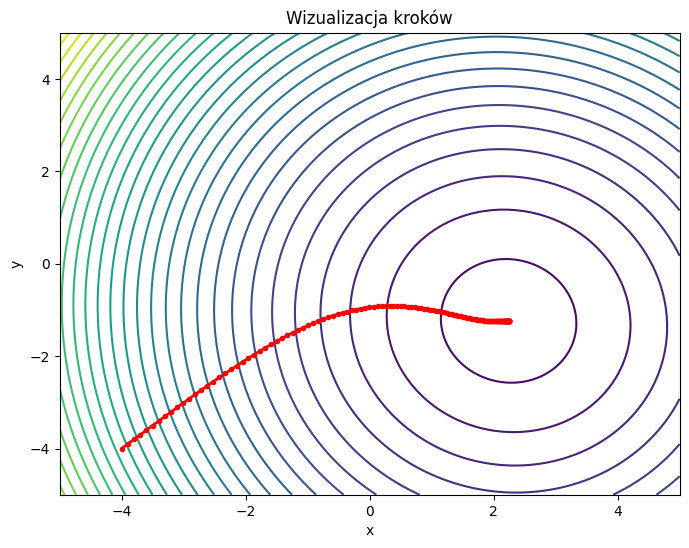

theta_T = [ 2.24764026 -1.23564215]   f(theta_T) = -3.5754136547445747


In [28]:
import numpy as np
import matplotlib.pyplot as plt

def func(x, y):
    return 3.0*(x - 2.0)**2 + 2.0*(y + 1.0)**2 + 0.2*x*y - 1.2*x + 0.5*y     # definicja funkcji

def grad_func(x, y):
    grad_x = 6.0*(x - 2.0) + 0.2*y - 1.2
    grad_y = 4.0*(y + 1.0) + 0.2*x + 0.5
    return np.array([grad_x, grad_y], dtype=float)                           # ręcznie wpisany gradient
#
def adam_optimize(grad_fn, theta0, steps=200, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
    """
    Arguemnty:
        - grad_fn - funkcja celu
        - theta0 - punkt startwoy
        - steps - maksymalna liczba iteracji
        - lr - współczynnik uczenia(alfa)
        - beta1 i beta2 - współczynniki wygładzania ze standardowymi wartościami
        - eps 
        
    """
    theta = np.array(theta0, dtype=float)       # tablica na kolejne wartości theta
    m = np.zeros_like(theta)                    # 
    v = np.zeros_like(theta)
    path = [theta.copy()]         

    for t in range(1, steps + 1):
        g = grad_fn(theta[0], theta[1])          # wartość gradientu w punkcie theta

        m = beta1 * m + (1 - beta1) * g          
        v = beta2 * v + (1 - beta2) * (g * g)     

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())

    return np.array(path)

theta0 = (-4.0, -4.0)

path = adam_optimize(grad_func, theta0, steps=140, lr=0.1)

xs = np.linspace(-5, 5, 400)
ys = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(xs, ys)
Z = func(X, Y)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=35)
plt.plot(path[:, 0], path[:, 1], "-o", markersize=3, linewidth=2, color="red")
plt.title("Wizualizacja kroków")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

final = path[-1]
print("theta_T =", final, "  f(theta_T) =", func(final[0], final[1]))


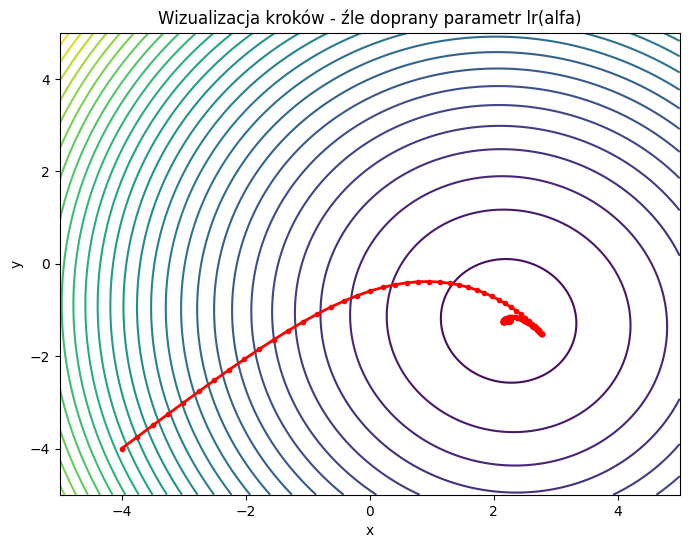

theta_T = [ 2.23660916 -1.23633471]   f(theta_T) = -3.5754779803084125


In [29]:
theta0 = (-4.0, -4.0)

path = adam_optimize(grad_func, theta0, steps=140, lr=0.25)       

xs = np.linspace(-5, 5, 400)
ys = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(xs, ys)
Z = func(X, Y)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=35)
plt.plot(path[:, 0], path[:, 1], "-o", markersize=3, linewidth=2, color="red")
plt.title("Wizualizacja kroków - źle doprany parametr lr(alfa)")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

final = path[-1]
print("theta_T =", final, "  f(theta_T) =", func(final[0], final[1]))

#### Istotność doobru parametrów
Drugi z wykresów ma służyć zobrazowaniu jak istotne są odpowiednio dobrane parametry. Na wykresie widzimy, że zbyt duży agrument $\alpha$ powoduje "przejście obok" szukanego ekstremum i powrót. Jasno widać dlaczego to niedobre - może dojść do sytuacji, że całkowicie ominięty zostanie punkt ekstremum lub dotarcie do niego zajmie niepotrzebnie wiele kroków. Odpowiedni dobór parametrów jest problemem samym w sobie, jednak pominę ten temat, jako że nie jest to główny temat opracownia.


#### Numeryczne obliczanie wartości gradientu
Powyżej pozwoliłem sobie na pewne uproszczenie: ręcznie wpisałem definicję gradientu funkcji $f$. Oczywiście nie jest możliwe wypisanie wszystkich możliwych funkcji, policzenia gradientów i zapisania ich w pamięci. Spróbujmy zastosować liczenie gradientu numerycznie. Jednak warto zaznaczyć, że to znacznie uproszczony wzór - faktyczne sposoby są znacznie bardziej wyszukane i korzystają z wielu usprawień.

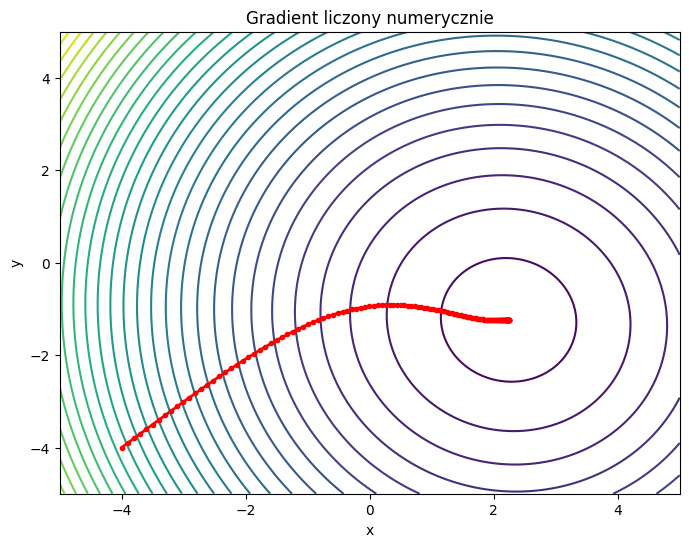

theta_T = [ 2.24764026 -1.23564215]   f(theta_T) = -3.5754136547445747


In [30]:
def grad_func_num(x, y):
    h = np.float64(0.1e-15)                   # możliwie mała, niezerowa wartość h - symylujemy liczenie granicy h -> 0
    grad_x = (func(x + h, y) - f(x, y)) / h   # liczymy ze wzoru na iloraz różnicowy
    grad_y = (func(x, y + h) - f(x, y)) / h   # to samo dla kolejnej pochodnej cząstkowej
    return np.array([grad_x, grad_y], dtype=float)

def adam_optimize_num(grad_fn, theta0, steps=200, lr=0.1, beta1=0.9, beta2=0.999, eps=1e-8):
    theta = np.array(theta0, dtype=float)
    m = np.zeros_like(theta)
    v = np.zeros_like(theta)
    path = [theta.copy()]

    for t in range(1, steps + 1):
        g = grad_func_num(theta[0], theta[1])          # wartość gradientu w punkcie theta, tym razem policzona z definicji

        m = beta1 * m + (1 - beta1) * g          
        v = beta2 * v + (1 - beta2) * (g * g)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        theta = theta - lr * m_hat / (np.sqrt(v_hat) + eps)
        path.append(theta.copy())

    return np.array(path)

theta0 = (-4.0, -4.0)

path = adam_optimize(grad_func, theta0, steps=140, lr=0.1)

xs = np.linspace(-5, 5, 400)
ys = np.linspace(-5, 5, 400)
X, Y = np.meshgrid(xs, ys)
Z = func(X, Y)

plt.figure(figsize=(8, 6))
plt.contour(X, Y, Z, levels=35)
plt.plot(path[:, 0], path[:, 1], "-o", markersize=3, linewidth=2, color="red")
plt.title("Gradient liczony numerycznie")
plt.xlabel("x")
plt.ylabel("y")
plt.show()

final = path[-1]
print("theta_T =", final, "  f(theta_T) =", func(final[0], final[1]))

#### Warunek stopu
W powyższej implementacji wybór warunku stopu przez osiągniecie maksymalnej liczby iteracji jest świadomym wyborem, jako że właśnie ten sposób jest najczęściej spotykany w uczeniu maszynowym przy trenowaniu sieci. Inne metody, dla ustalonego $\epsilon \gt 0$
- Dostatecznie mały krok: $|f(\theta_t) - f(\theta_{t-1})| < \epsilon$
- Różnica parametrów w granicy tolerancji: $||\theta_t - \theta_{t-1}|| < \epsilon$
- Norma gradientu: $||\nabla f(\theta_t)|| < \epsilon$

W każdym z tych przypadków należy również określić stosowaną metrykę.

## Przykład zastosowania w trenowaniu NNUE(EUNN - Efficiently Updatable Neural Network)

#### Model sieci neuronowej w ujęciu matematycznym (FWZ)

Sieć neuronową można opisać jako złożenie funkcji (warstw), które mapuje wektor cech wejściowych $x \in \mathbb{R}^{n_0}$ na wyjście $\hat y \in \mathbb{R}^{n_L}$. Parametry sieci (wagi i biasy) oznaczmy zbiorczo przez $\theta$. Wtedy sieć realizuje funkcję

$$
F_\theta:\mathbb{R}^{n_0}\to \mathbb{R}^{n_L}, \qquad \hat y = F_\theta(x).
$$

Najczęściej jest to kompozycja $L$ warstw: $F_\theta(x)=f_L\circ f_{L-1}\circ \dots \circ f_1(x)$, gdzie każda warstwa ma własny zbiór parametrów $\theta_\ell$.

#### Zmienne i parametry (dla warstwy $\ell$)
- **wektor aktywacji (wejście warstwy):** $a^{(\ell-1)} \in \mathbb{R}^{n_{\ell-1}}$, przy czym $a^{(0)}=x$
- **macierz wag:** $W^{(\ell)} \in \mathbb{R}^{n_\ell \times n_{\ell-1}}$
- **wektor biasów:** $b^{(\ell)} \in \mathbb{R}^{n_\ell}$
- **wektor preaktywacji:** $z^{(\ell)} \in \mathbb{R}^{n_\ell}$
- **funkcja aktywacji (stosowana elementowo):** $\sigma^{(\ell)}:\mathbb{R}\to\mathbb{R}$
- **wektor aktywacji (wyjście warstwy):** $a^{(\ell)} \in \mathbb{R}^{n_\ell}$

#### Warstwa w pełni połączona (afiniczna) + aktywacja
Podstawowym blokiem jest warstwa w pełni połączona (liniowa/afiniczna), w której dla $\ell=1,\dots,L$ definiuje się

$$
z^{(\ell)} = W^{(\ell)} a^{(\ell-1)} + b^{(\ell)}, \qquad a^{(\ell)} = \sigma^{(\ell)}\!\left(z^{(\ell)}\right).
$$

W ten sposób cała sieć (np. MLP) ma postać $F_\theta(x)=a^{(L)}$, a zbiór parametrów można zapisać jako $\theta=\{W^{(\ell)}, b^{(\ell)}\}_{\ell=1}^L$.

#### Przykładowe funkcje aktywacji
Typowe aktywacje to m.in. $\mathrm{ReLU}(t)=\max(0,t)$, $\tanh(t)$ oraz sigmoid $\sigma(t)=\frac{1}{1+e^{-t}}$.

#### Inne rodzaje warstw (ogólnie)
Poza warstwami afinicznymi spotyka się inne typy warstw, które również są przekształceniami $f_\ell(\cdot;\theta_\ell)$: warstwy konwolucyjne (splot z jądrami), normalizacyjne (np. batch normalization) oraz warstwy łączące (np. sumowanie/konkatenacja). Niezależnie od typu, sieć pozostaje kompozycją przekształceń parametryzowanych, a parametry $\theta$ determinują jej zachowanie.

### Uczenie sieci

#### Idea uczenia
Uczenie sieci neuronowej polega na takim dobraniu parametrów modelu, aby dla danych wejściowych sieć zwracała wyniki możliwie zgodne z oczekiwanymi odpowiedziami. Parametrami, które podlegają uczeniu, są przede wszystkim macierze wag $W^{(\ell)}$ oraz wektory biasów $b^{(\ell)}$ w kolejnych warstwach. Intuicyjnie można to rozumieć jako „dostrajanie” siły połączeń pomiędzy neuronami: jeśli pewne cechy wejściowe powinny zwiększać wynik, odpowiadające im wagi są wzmacniane, a jeśli powinny go zmniejszać — osłabiane. 

Formalnie zakładamy, że dysponujemy zbiorem danych uczących złożonym z par $(x_i, y_i)$, gdzie $x_i$ jest wejściem (np. wektorem cech), a $y_i$ jest pożądanym wyjściem (np. etykietą klasy lub wartością liczbową). Sieć o parametrach $\theta$ generuje predykcję $\hat y_i = F_\theta(x_i)$. Celem uczenia jest znalezienie takich parametrów $\theta$, dla których różnica pomiędzy $\hat y_i$ i $y_i$ jest możliwie mała, w sensie pewnego przyjętego kryterium jakości.

#### Funkcja straty i problem optymalizacji
W celu wyznacznia odpowiednich parametrów i znaleznienie tych najbliższych tym optymalnym definiuje się funkcję straty $\mathcal{L}(\theta)$. Więc zadanie nauczania sprowadzamy do wyznacznia i tutaj właśnie pojawia się omawiana **metoda gradientowa**.
$$
\theta^* = arg \min_{\theta}\, \mathcal{L}(\theta).
$$

#### Metoda propagacji wstecznej

W propagacji wstecznej wyznaczamy pochodne funkcji straty $\mathcal{L}$ względem parametrów $\theta=\{W^{(\ell)}, b^{(\ell)}\}_{\ell=1}^L$. Dla każdej zmiennej pośredniej $u$ wprowadzamy oznaczenie $du=\frac{\partial \mathcal{L}}{\partial u}$. Gradienty obliczane są w odwrotnej kolejności zależności w grafie obliczeń, lokalnie przez regułę łańcuchową. 

Jeśli $z=f(x,y)$ i znany jest gradient napływający $dz$, to:
- $dx \mathrel{+}= dz \cdot \frac{\partial z}{\partial x}$
- $dy \mathrel{+}= dz \cdot \frac{\partial z}{\partial y}$

Operator $\mathrel{+}=$ jest istotny: gdy zmienna wpływa na $\mathcal{L}$ kilkoma ścieżkami, jej gradient jest sumą wkładów z tych ścieżek (akumulacja).   
W praktyce przechowuje się wartości pośrednie potrzebne w backward (cache), np. maskę dla ReLU albo wektor $a^{(\ell-1)}$. 

Najczęstsze reguły „bramek”:
- dodawanie $z=x+y$: $dx \mathrel{+}= dz$, $dy \mathrel{+}= dz$ 
- mnożenie $z=xy$: $dx \mathrel{+}= dz\cdot y$, $dy \mathrel{+}= dz\cdot x$ 
- maksimum $z=\max(x,y)$: $dx \mathrel{+}= dz\cdot \mathbf{1}_{x\ge y}$, $dy \mathrel{+}= dz\cdot \mathbf{1}_{y\ge x}$ 
- ReLU $z=\max(0,x)$: $dx \mathrel{+}= dz \cdot \mathbf{1}_{x>0}$ 

Dla warstwy w pełni połączonej:
$$
z^{(\ell)} = W^{(\ell)} a^{(\ell-1)} + b^{(\ell)}, \qquad a^{(\ell)} = \sigma^{(\ell)}\!\left(z^{(\ell)}\right).
$$

Przy znanym $da^{(\ell)}$:
- $dz^{(\ell)} = da^{(\ell)} \odot \sigma^{(\ell)\prime}\!\left(z^{(\ell)}\right)$
- $dW^{(\ell)} = dz^{(\ell)} \cdot \left(a^{(\ell-1)}\right)^T$
- $db^{(\ell)} = dz^{(\ell)}$
- $da^{(\ell-1)} = \left(W^{(\ell)}\right)^T \cdot dz^{(\ell)}$

Weryfikacja przez wymiary: $dW^{(\ell)}$ ma kształt $n_\ell\times n_{\ell-1}$, $db^{(\ell)}$ ma kształt $n_\ell$, a $da^{(\ell-1)}$ ma kształt $n_{\ell-1}$. 


## 1. Czym jest NNUE? 
### 1.1 Ogólna idea
NNUE jest odmianą klasycznej sieci neuronowej krótko opisaną powyżej, której główną ideą jest wykorzysywanie wiedzy, gdy kolejne różne zestawy danych wejściowych niewiele się od siebie różnią. Można również powiedzieć, że jest to model architektoniczny sieci neuronowych lub sposób obliczeń w sieci.

Trzy główne zasady NNUE
1. Względnie niewielka liczba niezerowych cech.
2. Kolejne zestawy danych wejściowych powinny różnić się możliwe najmniej.
3. Sieć powinna być na tyle prosta, aby umożliwiać wnioskowanie o niskiej precyzji w dziedzinie liczb całkowitych.

### 1.2 Standardowa postać NNUE
Definicja tego rodzaju sieci nie narzuca zbyt wielu ograniczień, jednak sa pewne stadardy wykorzysywane przez znaczną większość implementacji. Oto kilka cech, które są standardem, chociaż NIE są wymuszone oraz uzasadnienie.

a) Zestaw cech wejściowych jest zwykle z góry zdefiniowany (skończona „słownikowa” lista możliwych cech), a pojedynczy przykład jest reprezentowany jako rzadki wektor binarny (multi-hot): cecha jest albo aktywna (1), albo nieaktywna (0). Dzięki temu pierwsza warstwa sprowadza się do sumowania wkładów aktywnych cech, co daje szybkie aktualizacje przez dodawanie/odejmowanie przy małych zmianach.

b) Sieć płytka - Chociaż definicja tego nie wymusza, to praktyczne implementacje NNUE są zazwyczaj sieciami płytkimi. Dlaczego? Są ku temu konkretne powody. Zasada 3. wprost mówi, że sieć powinna być dostatecznie prosta. Daje to kilka istotntych zalet m. in. 
 - wydajność - sieć o nieiwelkiej liczbie warstw będzie szybsza do policzenia przy względnie podobnej szerokowści warstw. Jest to kompromis między dokładnością obliczeń a właśnie wydajnością - zyski z kolejnych warstw mogą być nieproporcjonalne do kosztu obliczeń.
- błąd. Każda warstwa oznacza dodatkowe obliczenia, a co za tym idzie błędy przy zaokrąglaniu i obcinianiu
- łatwość w przejściu na obliczenia w liczbach całkowitych

Ponownie podkreślę, że to nie jest definicja ani wymóg. Zwyczajnie ten model sieci sprawdza się najlepiej w praktycznych zastosowaniach.

## 2. Szczegóły na przykładzie - silnik szachowy
Żeby lepiej zrozumieć ideę najłatwiej będzie pokazać architekturę na konkretnych przykładzie - silnik szachowy. Szachy są jednym z najbardziej znaczących zastosowań NNUE. Przejdźmy cały proces od początku.

### 2.1 Architektura
#### 2.1.1 Dane wejściowe
Szachy są idealnym uzsadanieniem reguły z podpunktu 1.2 a). W uproszczonym modelu zbiorem danych wejściowych są wektory cech:(pozycja, typ figury. kolor). Liczebność zbioru wynosi wtedy $ 64 \cdot 6 \cdot 2 =  768$ - 64 pola, 6 różnych typów figur i 2 kolory. Jeśli dana cecha wsytępuje, to wartość jest 1 wpw. 0. Zauważmy, że taki model spełnia założenia 1. zasady NNUE, jako że na planszy mamy w jednym momencie maksymalnie 32 figury, więc maksymalnie mamy 32 niezerowe cechy na wejściu.

Szachy spełniają zasadę 2. NNUE, ponieważ każda kolejna pozycja różni się stosunkowo niewiele od poprzedniej: maksymalnie może zmienić się położenie dwóch figur(roszada lub bicie). Zobaczmy przykład:

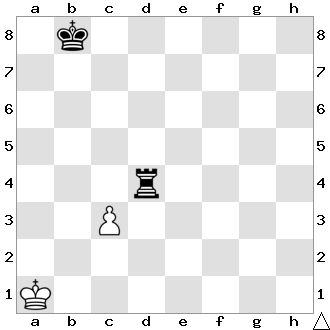

W tej pozycji, dla przyjętego wyżej modelu jedynymi niezerowymi cechami byłyby:
$$
(A1, king, white), (C3, pawn, white), (B8, king, black), (D4, rook, black)
$$

Po zagraniu ruchu c4 jedynie, co się zmieni, to cecha $(C3, pawn, white)$ musi zostać zamieniona na $(C4, pawn, white)$

### 2.2 Uczenie NNUE w silniku szachowym
W sieci neuronowej przeznaczonej do silnika szachowego uczenie odbywa się w dwóch krokach:
- przygotowanie danych:

    a) Zebraniu pozycji treningowych opisanych schematem jak wcześniej podany przykładowy
    
    b) Obliczeniu dla każdej pozycji oczekiwanej wartości. W przypadku silnika Stockfish ocena pozycji pochodzi od klasycznego silnika, nie używajacego NN, z     umiarkowaną głębią przeszukiwania. Ta wartość jest tą oczekiwaną, tę funkcję chcemy przybliżyć za pomocą sieci

- faktyczne uruchomienie algorytmu treningowego

  a) Specyfikacja modelu NNUE  
  W trenerze definiuje się sieć z warstwą feature transformer (liniowa na wejściu rzadkim) oraz kolejnymi małymi warstwami liniowymi. Dwa widoki cech (perspektywa białych i czarnych) są liczone osobno, a następnie łączone w kolejności zależnej od strony na ruchu (stm). Nieliniowość realizuje się jako ClippedReLU = clamp(0..1).

  b) Szybkie przygotowanie batchy (C++ parser + rzadkie tensory)  
  Ponieważ parsowanie i składanie wejść w Pythonie byłoby zbyt wolne, w nnue-pytorch używa się szybkiego parsera w C++ (shared library) i interop przez ctypes. Czytnik danych uruchamia wątki robocze, które asynchronicznie przygotowują całe batch’e. Wejście buduje się jako jeden duży 2D tensor rzadki o indeksach (position_index, feature_index); dla wydajności korzysta się z _sparse_coo_tensor_unsafe(...) i oznacza tensor jako już coalesced (żeby uniknąć kosztownego porządkowania indeksów).

  c) Cel i funkcja straty (NNUE/Stockfish)  
  Docelowy score (z generatora danych) jest porównywany z wyjściem sieci, ale często robi się to nie w centipionach, tylko w WDL: wdl = $\sigma(cp / s)$
  gdzie s to współczynnik skali (np. rzędu ~400–410). Opcjonalnie miesza się ocenę z wynikiem partii parametrem lambda_. Jako loss stosuje się zwykle MSE w WDL-space (czasem z wykładnikiem >2, np. 2.6) albo cross-entropy w WDL-space.

  d) Aktualizacja wag + ograniczenia pod kwantyzację  
  Po obliczeniu straty wykonywany jest standardowy krok optymalizatora (backprop + update). Jednocześnie trzeba pilnować zgodności z późniejszą kwantyzacją (np. int8): wagi warstw int8 mają ograniczony zakres, więc po każdym kroku uczenia wykonuje się clamp wag (wewnątrz optymalizatora lub „na zewnątrz”).

  e) (Opcjonalnie) Feature factorization w treningu  
  Aby szybciej „rozruszać” rzadkie cechy (np. HalfKP), można dodać wirtualne, gęstsze cechy tylko na czas treningu, a po treningu ich wpływ scala się (coalesce) do wag cech rzeczywistych.
  
### Przykład
Na koniec chciałbym pokazać absolutnie minimalistyczny przykład takiej sieci. Ocena pozcyji oczywiście nie jest nawet zbliżona do tej prawdziwej. żeby taką uzyskać można wprowadzić format FEN partii na stronie https://lichess.org/analysis

In [31]:
import numpy as np

# 1) "A" feature set (64 * 6 * 2 = 768)
# Każda cecha to (square, piece_type, color) ustawiona na 1 jeśli bierka stoi na polu.
# Przekazujemy tylko listę aktywnych indeksów (sparse)


PT = {'p':0,'n':1,'b':2,'r':3,'q':4,'k':5}  # piece_type: pawn..king

def a_features_active_indices(fen: str):
    board = fen.split()[0]
    ranks = board.split('/')
    active = []
    for r_i, rank_str in enumerate(ranks):
        rank = 8 - r_i
        file = 0
        for ch in rank_str:
            if ch.isdigit():
                file += int(ch)
            else:
                is_white = ch.isupper()
                color = 0 if is_white else 1     # 0=white, 1=black
                ptype = PT[ch.lower()]
                square = file + 8*(rank-1)       # A1=0, B1=1, ..., H8=63
                idx = (square * 6 + ptype) * 2 + color
                active.append(idx)
                file += 1
    return active

# Prosta "klasyczna" etykieta: material w centipionach
VAL = {'p':100,'n':320,'b':330,'r':500,'q':900,'k':0}
def material_cp(fen: str) -> float:
    board = fen.split()[0]
    s = 0
    for ch in board:
        if ch in "/12345678": 
            continue
        v = VAL[ch.lower()]
        s += v if ch.isupper() else -v
    return float(s)

# 2) Minimalna sieć NNUE: 768 -> 8 -> 8 -> 1 + ClippedReLU


def crelu(x):
    return np.clip(np.maximum(x, 0.0), 0.0, 1.0)

def d_crelu(x):
    # pochodna clamp(ReLU): 1 tylko dla 0<x<1
    return ((x > 0.0) & (x < 1.0)).astype(np.float32)

rng = np.random.default_rng(0)
M, K = 8, 8
W0 = (rng.normal(0, 1, (M, 768)) * 0.05).astype(np.float32)
b0 = np.zeros((M,), np.float32)
W1 = (rng.normal(0, 1, (K, M)) * 0.05).astype(np.float32)
b1 = np.zeros((K,), np.float32)
W2 = (rng.normal(0, 1, (1, K)) * 0.05).astype(np.float32)
b2 = np.zeros((1,), np.float32)

params = {"W0":W0,"b0":b0,"W1":W1,"b1":b1,"W2":W2,"b2":b2}

def forward(active_idx, P):
    # sparse "first layer": a0 = b0 + sum kolumn wag dla aktywnych cech
    a0 = P["b0"].copy()
    if active_idx:
        a0 += np.sum(P["W0"][:, active_idx], axis=1)
    h0 = crelu(a0)

    a1 = P["W1"] @ h0 + P["b1"]
    h1 = crelu(a1)

    out = (P["W2"] @ h1 + P["b2"])[0]   # skalar
    return a0, h0, a1, h1, out

def mse_loss(preds, targets):
    d = preds - targets
    return float(np.mean(d*d))


# 3) Adam

opt = {}
for k, v in params.items():
    opt[k] = {"m": np.zeros_like(v), "v": np.zeros_like(v)}

def adam_step(P, G, opt, t, lr=0.05, beta1=0.9, beta2=0.999, eps=1e-8):
    for k in P.keys():
        m = opt[k]["m"]
        v = opt[k]["v"]
        g = G[k]

        m[:] = beta1*m + (1-beta1)*g
        v[:] = beta2*v + (1-beta2)*(g*g)

        m_hat = m / (1 - beta1**t)
        v_hat = v / (1 - beta2**t)

        P[k] -= lr * m_hat / (np.sqrt(v_hat) + eps)

# -----------------------------
# 4) Mini-dataset (dla demonstracji)
# -----------------------------
FENS = [
    "1k6/8/8/8/3r4/2P5/8/K7 w - - 0 1",  # pawn vs rook
    "1k6/8/8/8/8/2P5/8/K7 w - - 0 1",
    "1k6/8/8/8/3q4/2P5/8/K7 w - - 0 1",
    "1k6/8/8/8/3r4/8/8/K7 w - - 0 1",
    "1k6/8/8/8/8/8/8/K7 w - - 0 1",
    "1k6/8/8/8/8/8/8/K6Q w - - 0 1",
    "1k6/8/8/8/8/8/4n3/K7 w - - 0 1",
    "1k6/8/8/8/8/8/4N3/K7 w - - 0 1",
    "1k6/8/8/8/8/8/4B3/K7 w - - 0 1",
    "1k6/8/8/8/8/8/4b3/K7 w - - 0 1",
    "1k6/8/8/8/8/8/3r4/K2R4 w - - 0 1",
    "1k6/8/8/8/8/8/3q4/K2R4 w - - 0 1",
]

X = [a_features_active_indices(f) for f in FENS]
y = np.array([material_cp(f) for f in FENS], dtype=np.float32)


# 5) Trening
steps = 10000
lr = 0.01

for t in range(1, steps+1):
    # grad init
    G = {k: np.zeros_like(v) for k, v in params.items()}

    preds = np.zeros_like(y)
    for i, active in enumerate(X):
        a0, h0, a1, h1, out = forward(active, params)
        preds[i] = out

        # dL/dout dla MSE: 2*(out-y)/N
        N = len(X)
        d_out = (2.0 / N) * (out - y[i])  # skalar

        # warstwa 2
        G["W2"] += d_out * h1[None, :]
        G["b2"] += np.array([d_out], dtype=np.float32)

        # back do h1
        d_h1 = (params["W2"].T[:,0] * d_out)          # (K,)
        d_a1 = d_h1 * d_crelu(a1)                     # (K,)

        # warstwa 1
        G["W1"] += d_a1[:, None] @ h0[None, :]
        G["b1"] += d_a1

        # back do h0
        d_h0 = params["W1"].T @ d_a1                  # (M,)
        d_a0 = d_h0 * d_crelu(a0)                     # (M,)

        # bias first layer
        G["b0"] += d_a0

        # sparse grad dla W0: tylko aktywne kolumny dostają update
        for idx in active:
            G["W0"][:, idx] += d_a0

    adam_step(params, G, opt, t, lr=lr)

    if t % 2000 == 0:
        print(f"step {t:4d} | mse={mse_loss(preds, y):.2f}")

# -----------------------------
# 6) Wynik
# -----------------------------
print("\nTarget material (cp):", y.astype(int))
pred_final = np.array([forward(active, params)[-1] for active in X])
print("Pred (cp):", np.round(pred_final, 1))


step 2000 | mse=177009.69
step 4000 | mse=157177.42
step 6000 | mse=141145.94
step 8000 | mse=126455.43
step 10000 | mse=113352.09

Target material (cp): [-400  100 -800 -500    0  900 -320  320  330 -330    0 -400]
Pred (cp): [-256.8   24.  -256.8 -256.8   24.    24.  -256.8   24.    24.  -256.8
   24.  -256.8]


## Autor tekstu: Wiktor Wdowczyk
## Źródła
- https://official-stockfish.github.io/docs/nnue-pytorch-wiki/docs/nnue.html
- https://cs231n.github.io/optimization-2/
- https://www.chessprogramming.org/NNUE
- https://www.geeksforgeeks.org/deep-learning/adam-optimizer/
- https://d2l.ai/
- https://programistamag.pl/wp-content/uploads/downloads/Programista_111_Sieci_neuronowe.pdf
- Analiza matematyczna z zastosowaniami 2, Wykłady - prof. UAM dr hab. Mieczysław Cichoń